## This is how Bagging/RandomForest works Internally By Using Row Sampling

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

#### Generating a Synthetic Classification Dataset

In [2]:
X , y = make_classification(n_features=5, n_informative=5, n_redundant=0, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X , columns=['col1', 'col2' , 'col3', 'col4', 'col5'])
df['target'] = y

In [4]:
df

,col1,col2,col3,col4,col5,target
0,4.333045,-0.322887,1.152398,-3.195687,-0.267089,0
1,-0.286786,0.729653,3.542417,1.254137,0.645548,1
2,-0.403546,1.343347,1.128083,0.521121,1.723770,1
3,-0.897021,-1.611065,-2.711649,0.392179,2.034521,0
4,-2.261456,-1.794361,-2.780560,0.594411,1.388125,0
...,...,...,...,...,...,...
95,1.208642,4.546144,2.778227,1.209182,-1.531185,1
96,1.717529,-1.785029,-1.949973,0.028341,2.356078,0
97,-0.625072,-1.433556,-1.547852,-1.223306,1.545524,0
98,0.842766,-1.203637,-1.972296,-0.691068,1.213435,0


In [5]:
df.shape

(100, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col1    100 non-null    float64
 1   col2    100 non-null    float64
 2   col3    100 non-null    float64
 3   col4    100 non-null    float64
 4   col5    100 non-null    float64
 5   target  100 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 4.8 KB


In [7]:
df.head()

,col1,col2,col3,col4,col5,target
0,4.333045,-0.322887,1.152398,-3.195687,-0.267089,0
1,-0.286786,0.729653,3.542417,1.254137,0.645548,1
2,-0.403546,1.343347,1.128083,0.521121,1.723770,1
3,-0.897021,-1.611065,-2.711649,0.392179,2.034521,0
4,-2.261456,-1.794361,-2.780560,0.594411,1.388125,0


### Function for Row Sampling

In [8]:
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True) #with replacement

### Using Row Sampling

#### `RandomForest` is collection of decision tree 
Now we will Create 3 new datasets using Row Sampling With Replacement

In [9]:
df1 = sample_rows(df,0.2)
df1

,col1,col2,col3,col4,col5,target
5,-1.940692,0.569869,0.032122,0.684628,1.280457,1
32,1.315740,-0.083381,-0.620797,-2.404077,0.394960,0
40,0.280422,2.549306,2.555950,0.469608,0.296758,1
99,0.034675,0.746764,2.608833,2.724766,0.546646,1
5,-1.940692,0.569869,0.032122,0.684628,1.280457,1
98,0.842766,-1.203637,-1.972296,-0.691068,1.213435,0
35,-1.804278,-1.258668,1.904503,1.296003,2.188577,1
56,0.377761,2.695826,2.136824,0.661217,0.372511,1
87,-0.718793,0.745037,1.140025,0.896015,1.743459,1
47,0.405802,0.610727,0.828317,0.674028,3.399261,1


In [10]:
df2 = sample_rows(df,0.2)
df2

,col1,col2,col3,col4,col5,target
7,-0.915956,-0.785148,-1.445838,-0.022341,-0.280338,0
44,1.073534,-1.106480,-0.912567,-0.719830,0.948607,0
2,-0.403546,1.343347,1.128083,0.521121,1.723770,1
39,1.056419,-0.522333,-1.913365,0.931378,1.041006,0
29,-0.209281,-2.657080,-1.849052,-0.320417,2.463300,0
28,-1.796161,-0.194556,-0.613643,2.636507,1.222475,1
68,-0.030113,-0.086619,-0.892483,0.679979,-0.816807,0
32,1.315740,-0.083381,-0.620797,-2.404077,0.394960,0
20,3.234541,0.635591,0.260751,-1.980112,-1.211580,0
43,3.609155,0.399763,1.121686,-1.677340,-0.275906,0


In [11]:
df3 = sample_rows(df,0.2)
df3

,col1,col2,col3,col4,col5,target
21,1.265894,-1.586378,-0.866472,-1.135995,1.523181,0
54,0.339283,0.625470,2.670796,0.146081,2.240497,1
95,1.208642,4.546144,2.778227,1.209182,-1.531185,1
9,-0.386554,-1.878717,-2.833688,0.739626,4.269959,0
26,0.279646,-2.743041,-2.111037,-1.737727,3.110938,0
70,0.422422,3.768998,1.976688,1.375670,-1.158471,1
31,-1.387703,1.774472,-0.352959,1.444888,-0.138360,1
59,1.289460,-0.517866,-0.693804,-0.691435,0.594426,0
71,0.012364,1.577687,1.753143,1.032071,1.196662,1
84,0.859506,1.989459,3.848057,-0.602111,1.469540,1


In [12]:
print(df1.shape,
df2.shape,
df3.shape)

(20, 6) (20, 6) (20, 6)


#### calling decisiontreeClassifier and making objects for my 3 datasets 

In [13]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [14]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### ploting 3 decision tree by row sampling

In [15]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[3] <= 0.224\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.625, 0.5, '  False')]

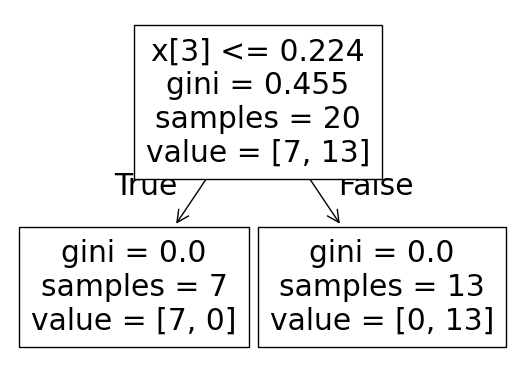

In [16]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[3] <= 0.2\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= -0.753\ngini = 0.278\nsamples = 12\nvalue = [2, 10]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]')]

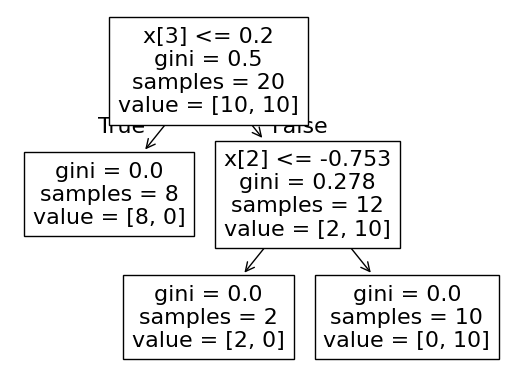

In [17]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[2] <= 1.332\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.4, 0.5, 'x[3] <= 1.092\ngini = 0.298\nsamples = 11\nvalue = [9, 2]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.7, 0.6666666666666667, '  False')]

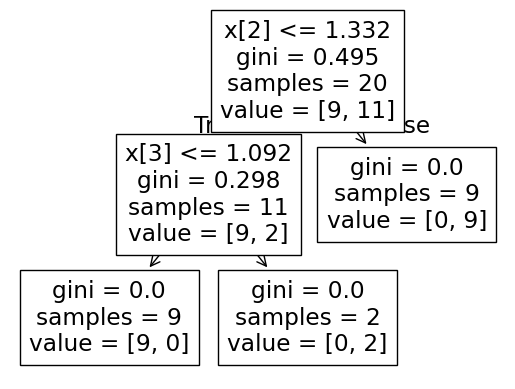

In [18]:
plot_tree(clf3)

### we will predict a random datapoint manually to see how the each Decision Tree is Predicting 


In [19]:
clf1.predict(np.array([-0.299745,	-0.347790,	-1.841516,	2.494107,	-0.930267]).reshape(1,5))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [20]:
clf2.predict(np.array([-0.299745,	-0.347790,	-1.841516,	2.494107,	-0.930267]).reshape(1,5))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [21]:
clf3.predict(np.array([-0.299745,	-0.347790,	-1.841516,	2.494107,	-0.930267]).reshape(1,5))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

#### Query point Answer should be `1`